<a href="https://colab.research.google.com/github/Ayazmj/northstar-database-analytics-coursework/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - R Analytics and Statistical Analysis

This notebook performs statistical and visual analysis on the cleaned NorthStar datasets using R. The analysis focuses on delivery performance, customer complaints, driver performance, app reliability, and relationships between operational variables.

The objective is to generate evidence-based insights using descriptive statistics, grouped summaries, correlation analysis, and ggplot2 visualisations.

In [1]:
install.packages("tidyverse")
install.packages("readr")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("corrplot")

library(tidyverse)
library(readr)
library(dplyr)
library(ggplot2)
library(corrplot)

print("R analytics packages loaded successfully.")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded



[1] "R analytics packages loaded successfully."


## Data Loading

The cleaned datasets used in this notebook were generated from the Python data processing notebook and exported as CSV files. Due to Google Colab R runtime access limitations, the cleaned dataset ZIP file is uploaded into the notebook runtime and extracted locally before analysis.

In [2]:
unzip("/content/cleaned_data.zip", exdir = "/content/cleaned_data")

print("Files extracted:")
print(list.files("/content/cleaned_data"))

[1] "Files extracted:"
[1] "app_events_cleaned.csv" "complaints_cleaned.csv" "customers_cleaned.csv" 
[4] "deliveries_cleaned.csv" "drivers_cleaned.csv"    "hubs_cleaned.csv"      
[7] "incidents_cleaned.csv"  "orders_cleaned.csv"     "vehicles_cleaned.csv"  


In [3]:
cleaned_path <- "/content/cleaned_data"

customers <- read_csv(file.path(cleaned_path, "customers_cleaned.csv"))
orders <- read_csv(file.path(cleaned_path, "orders_cleaned.csv"))
deliveries <- read_csv(file.path(cleaned_path, "deliveries_cleaned.csv"))
drivers <- read_csv(file.path(cleaned_path, "drivers_cleaned.csv"))
vehicles <- read_csv(file.path(cleaned_path, "vehicles_cleaned.csv"))
hubs <- read_csv(file.path(cleaned_path, "hubs_cleaned.csv"))
complaints <- read_csv(file.path(cleaned_path, "complaints_cleaned.csv"))
incidents <- read_csv(file.path(cleaned_path, "incidents_cleaned.csv"))
app_events <- read_csv(file.path(cleaned_path, "app_events_cleaned.csv"))

print("Cleaned datasets loaded successfully.")

Rows: 650 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (4): age, loyalty_score, app_engagement_score, account_status_failure_flag
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 14
── Column specification ──────────────────────────────────────────────────

[1] "Cleaned datasets loaded successfully."


## Dataset Overview

This section summarises the number of records and variables available in each cleaned dataset.

In [4]:
dataset_summary <- data.frame(
  dataset = c("customers", "orders", "deliveries", "drivers", "vehicles", "hubs", "complaints", "incidents", "app_events"),
  rows = c(nrow(customers), nrow(orders), nrow(deliveries), nrow(drivers), nrow(vehicles), nrow(hubs), nrow(complaints), nrow(incidents), nrow(app_events)),
  columns = c(ncol(customers), ncol(orders), ncol(deliveries), ncol(drivers), ncol(vehicles), ncol(hubs), ncol(complaints), ncol(incidents), ncol(app_events))
)

dataset_summary

dataset,rows,columns
<chr>,<int>,<int>
customers,650,10
orders,1250,11
deliveries,950,14
drivers,170,8
vehicles,120,9
hubs,8,5
complaints,320,12
incidents,280,8
app_events,640,14


### Dataset Summary Interpretation

The cleaned NorthStar dataset contains nine related tables covering customers, orders, deliveries, drivers, vehicles, hubs, complaints, incidents, and app events. The largest dataset is the orders table with 1,250 records, followed by deliveries with 950 records and app events with 640 records. This shows that the analysis is mainly focused on operational delivery activity, customer interactions, and digital platform behaviour.

The presence of multiple linked datasets supports a relational analytical approach where delivery performance, customer experience, workforce performance, and app reliability can be analysed together.

## Descriptive Statistics

Descriptive statistics are used to understand the distribution of key numerical variables such as order value, route distance, customer rating, driver rating, training score, API latency, and complaint resolution time.

In [5]:
descriptive_stats <- data.frame(
  metric = c(
    "Order Value",
    "Route Distance KM",
    "Customer Rating Post Delivery",
    "Fuel or Charge Cost",
    "Driver Rating",
    "Training Score",
    "API Latency MS",
    "Complaint Resolution Days"
  ),
  mean = c(
    mean(orders$order_value, na.rm = TRUE),
    mean(deliveries$route_distance_km, na.rm = TRUE),
    mean(deliveries$customer_rating_post_delivery, na.rm = TRUE),
    mean(deliveries$fuel_or_charge_cost, na.rm = TRUE),
    mean(drivers$driver_rating, na.rm = TRUE),
    mean(drivers$training_score, na.rm = TRUE),
    mean(app_events$api_latency_ms, na.rm = TRUE),
    mean(complaints$resolution_days, na.rm = TRUE)
  ),
  median = c(
    median(orders$order_value, na.rm = TRUE),
    median(deliveries$route_distance_km, na.rm = TRUE),
    median(deliveries$customer_rating_post_delivery, na.rm = TRUE),
    median(deliveries$fuel_or_charge_cost, na.rm = TRUE),
    median(drivers$driver_rating, na.rm = TRUE),
    median(drivers$training_score, na.rm = TRUE),
    median(app_events$api_latency_ms, na.rm = TRUE),
    median(complaints$resolution_days, na.rm = TRUE)
  ),
  sd = c(
    sd(orders$order_value, na.rm = TRUE),
    sd(deliveries$route_distance_km, na.rm = TRUE),
    sd(deliveries$customer_rating_post_delivery, na.rm = TRUE),
    sd(deliveries$fuel_or_charge_cost, na.rm = TRUE),
    sd(drivers$driver_rating, na.rm = TRUE),
    sd(drivers$training_score, na.rm = TRUE),
    sd(app_events$api_latency_ms, na.rm = TRUE),
    sd(complaints$resolution_days, na.rm = TRUE)
  )
)

descriptive_stats

metric,mean,median,sd
<chr>,<dbl>,<dbl>,<dbl>
Order Value,91.050520,76.530,60.9177833
Route Distance KM,13.909316,12.840,7.4779068
Customer Rating Post Delivery,3.867263,4.040,0.8880493
Fuel or Charge Cost,12.841295,12.645,4.3364683
Driver Rating,4.171706,4.175,0.4063010
Training Score,74.926471,75.200,10.9792787
API Latency MS,465.667188,432.500,271.6341555
Complaint Resolution Days,7.928125,7.000,5.2143240


### Descriptive Statistics Interpretation

The average order value is approximately 91.05, while the median is 76.53. This indicates that some high-value orders increase the overall average. The average route distance is around 13.91 km, showing that most deliveries are short to medium distance.

The average post-delivery customer rating is 3.87, while the average driver rating is 4.17. This suggests that driver ratings are generally stronger than customer delivery satisfaction. API latency has a high standard deviation, indicating inconsistent app performance across sessions. Complaint resolution takes an average of 7.93 days, which may indicate an area for customer service improvement.

### Interpretation

The descriptive statistics provide a high-level understanding of the main numerical variables in the dataset. Mean and median values help identify the typical level of performance, while standard deviation shows how much variation exists across operational, customer, driver, and app-related measures.

## Chart 1: Order Value Distribution

This chart shows the distribution of order values. It helps identify whether most orders are low, medium, or high value.

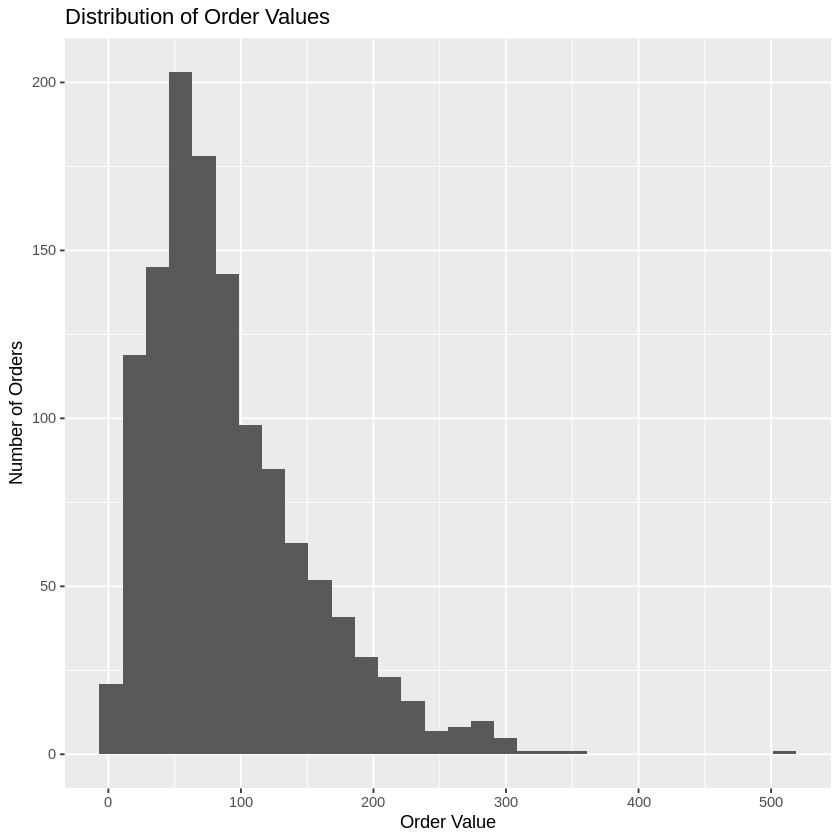

In [6]:
ggplot(orders, aes(x = order_value)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Order Values",
    x = "Order Value",
    y = "Number of Orders"
  )

### Chart Interpretation

The order value distribution is right-skewed, meaning most orders are concentrated in the lower to medium value range, while a smaller number of orders have very high values. This explains why the mean order value is higher than the median.

From a business perspective, NorthStar should treat high-value orders carefully because they may represent premium customers or important service transactions. However, operational efficiency should still focus on the majority of regular-value orders.

### Interpretation

The histogram shows how order values are distributed across the dataset. If most orders are concentrated in a lower or middle range, NorthStar may rely heavily on regular-value transactions. Any long tail or high-value concentration can help identify premium or high-priority service opportunities.

## Chart 2: Delivery Status by Service Type

This chart compares successful and failed deliveries across service types.

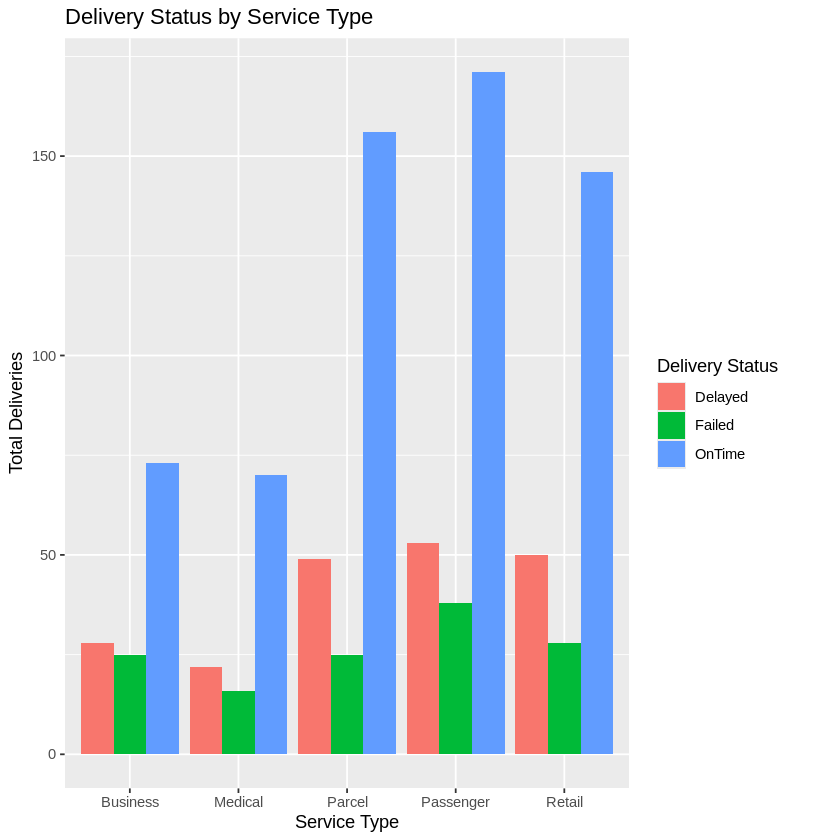

In [7]:
delivery_service_analysis <- orders %>%
  inner_join(deliveries, by = "order_id") %>%
  group_by(service_type, delivery_status) %>%
  summarise(total_deliveries = n(), .groups = "drop")

ggplot(delivery_service_analysis, aes(x = service_type, y = total_deliveries, fill = delivery_status)) +
  geom_col(position = "dodge") +
  labs(
    title = "Delivery Status by Service Type",
    x = "Service Type",
    y = "Total Deliveries",
    fill = "Delivery Status"
  )

### Chart Interpretation

The chart shows that on-time deliveries are the largest category across all service types. Passenger, Parcel, and Retail services have relatively high delivery volumes. However, delayed and failed deliveries are also visible across all service categories.

This suggests that although NorthStar performs well overall, service reliability issues still exist. Business and Retail services should be monitored closely because delivery failures and delays can directly affect customer satisfaction and operational reputation.


### Interpretation

The chart compares delivery outcomes across service types. Service types with a higher number of failed or problematic deliveries may require further operational investigation, especially where delivery volume is also high.

## Chart 3: Customer Rating by Service Type

This boxplot compares post-delivery customer ratings across different service types.

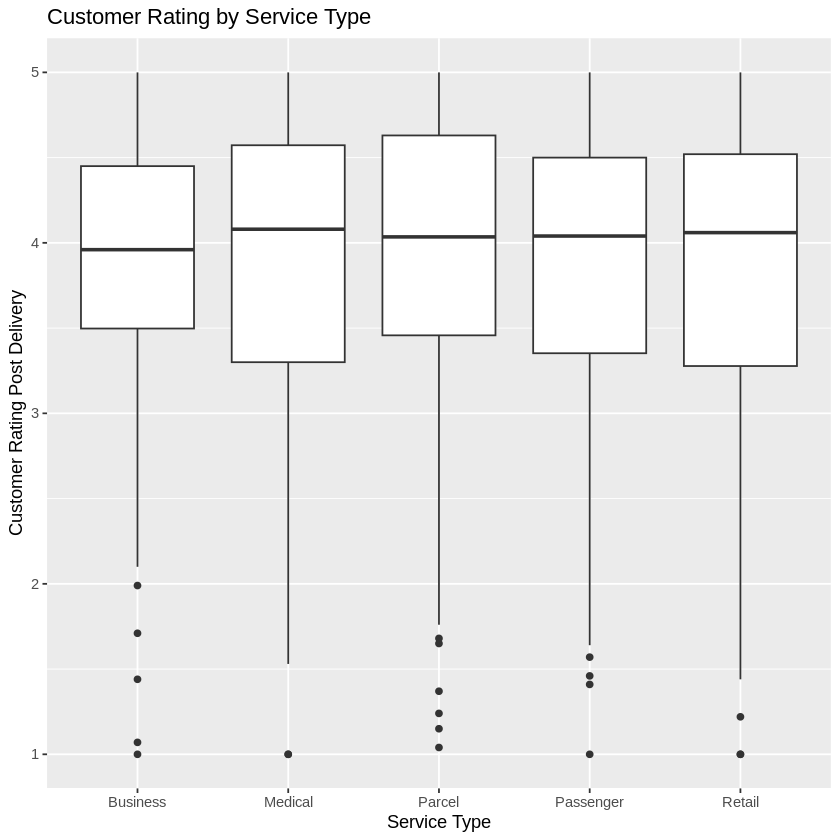

In [8]:
rating_service_data <- orders %>%
  inner_join(deliveries, by = "order_id")

ggplot(rating_service_data, aes(x = service_type, y = customer_rating_post_delivery)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating by Service Type",
    x = "Service Type",
    y = "Customer Rating Post Delivery"
  )

### Chart Interpretation

The boxplot shows that customer ratings are generally centred around 4 across all service types. This indicates a moderate to good level of customer satisfaction. However, there are low-rating outliers in every service type, showing that some customers had poor delivery experiences.

The presence of low-rating outliers suggests that NorthStar should investigate failed, delayed, or poorly rated deliveries to identify the operational causes behind customer dissatisfaction.

### Interpretation

The boxplot shows how customer satisfaction varies across service types. Lower median ratings or wider rating variation may indicate inconsistent service quality. This supports the SQL findings by linking operational performance with customer experience.

## Chart 4: Complaint Severity by Customer Type

This chart shows the number of complaints by customer type and severity level.

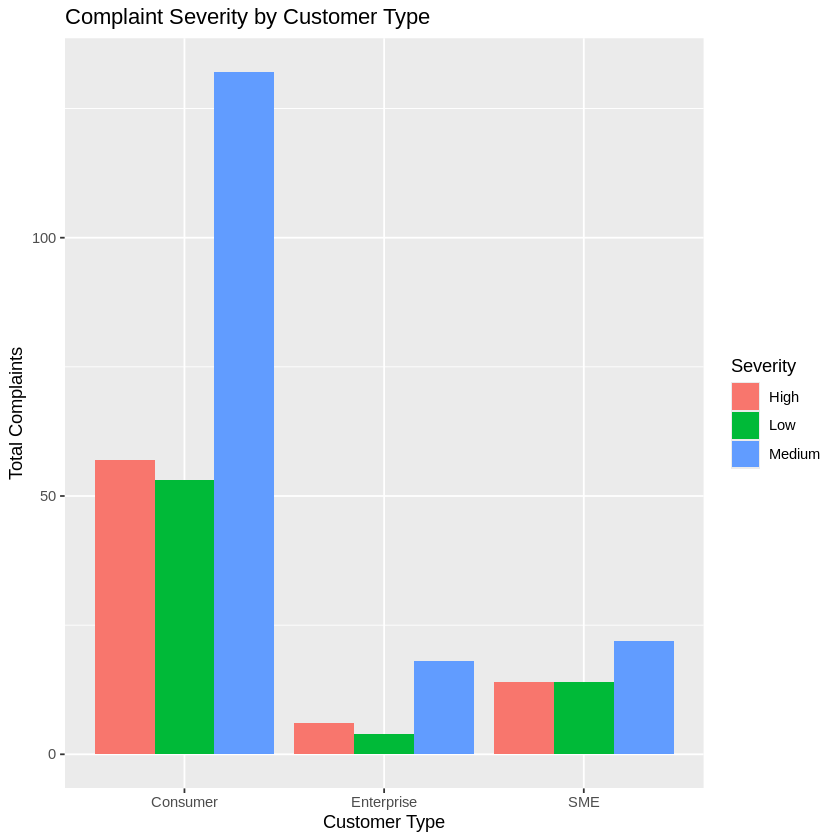

In [9]:
complaint_customer_analysis <- complaints %>%
  inner_join(customers, by = "customer_id") %>%
  group_by(customer_type, severity) %>%
  summarise(total_complaints = n(), .groups = "drop")

ggplot(complaint_customer_analysis, aes(x = customer_type, y = total_complaints, fill = severity)) +
  geom_col(position = "dodge") +
  labs(
    title = "Complaint Severity by Customer Type",
    x = "Customer Type",
    y = "Total Complaints",
    fill = "Severity"
  )

### Chart Interpretation

The complaint severity chart shows that Consumer customers generate the highest number of complaints across all severity levels. This is likely because the Consumer segment has a larger customer base or higher transaction frequency.

Medium severity complaints are especially high among Consumer customers. This suggests that NorthStar should prioritise complaint handling improvements for Consumer customers, while also monitoring SME and Enterprise complaints because these segments may have higher business value.

### Interpretation

The chart shows which customer segments experience the most complaints and how severe those complaints are. A high number of severe complaints in a customer group may indicate a need for improved support, faster resolution, or service quality intervention.

## Chart 5: Driver Rating and Training Score Relationship

This scatter plot examines whether driver training score is associated with driver rating.

`geom_smooth()` using formula = 'y ~ x'


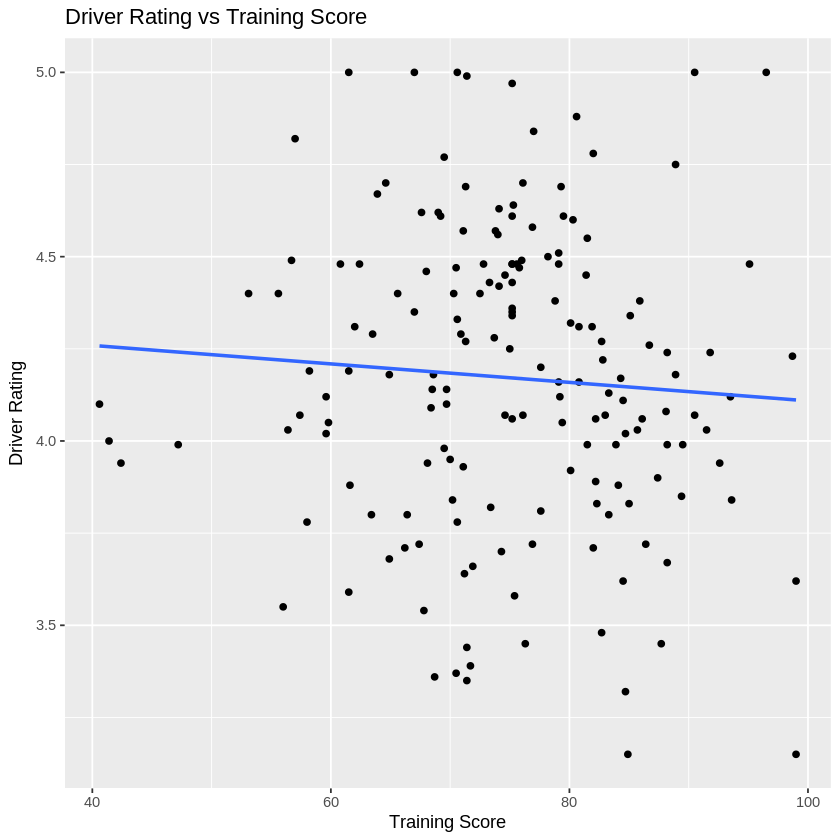

In [10]:
ggplot(drivers, aes(x = training_score, y = driver_rating)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Driver Rating vs Training Score",
    x = "Training Score",
    y = "Driver Rating"
  )

### Chart Interpretation

The scatter plot shows a weak relationship between driver training score and driver rating. The trend line is slightly negative, suggesting that higher training scores do not strongly translate into higher driver ratings in this dataset.

This indicates that driver performance may be influenced by other factors such as delivery route difficulty, customer behaviour, workload, vehicle condition, or hub operations. Therefore, training score alone should not be used as the only measure of driver performance.

### Interpretation

The scatter plot explores whether higher training scores are associated with better driver ratings. A positive trend would suggest that training quality may contribute to improved driver performance, while a weak trend would indicate that other factors also influence driver ratings.

## Chart 6: API Latency by Device Type

This boxplot compares API latency across device platforms.

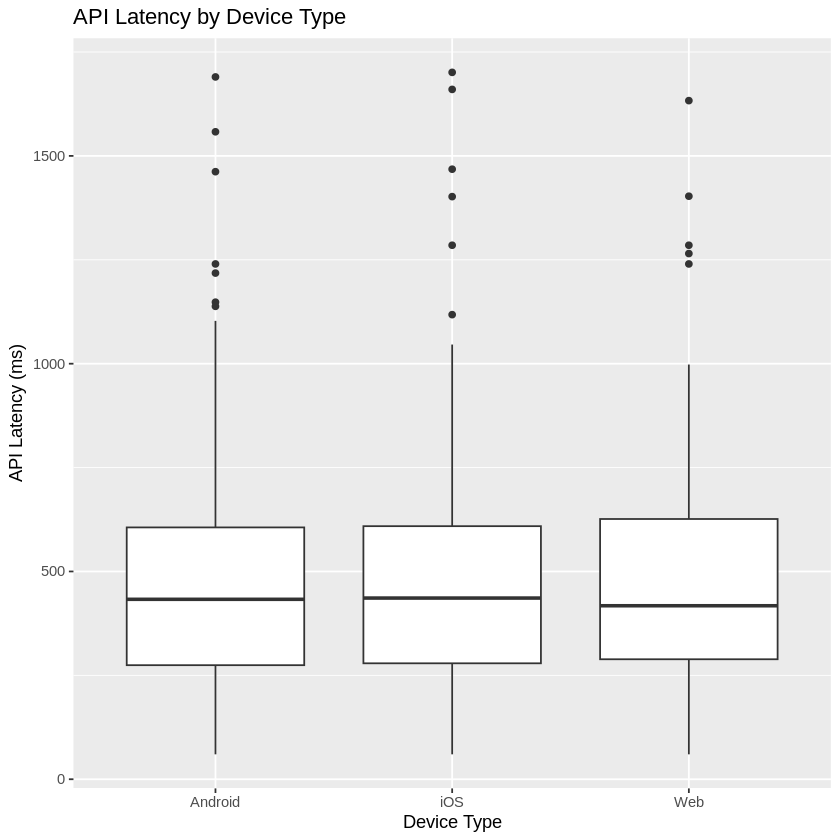

In [11]:
ggplot(app_events, aes(x = device_type, y = api_latency_ms)) +
  geom_boxplot() +
  labs(
    title = "API Latency by Device Type",
    x = "Device Type",
    y = "API Latency (ms)"
  )

### Chart Interpretation

The API latency boxplot shows that Android, iOS, and Web platforms have broadly similar median latency levels. However, all three platforms contain high-latency outliers, with some sessions exceeding 1,500 ms.

This indicates that app performance is inconsistent for some users. NorthStar should investigate high-latency events, especially where latency is connected with failed app actions, payment retries, or customer support escalation.

### Interpretation

The chart compares app performance across device types. Higher median latency or wider latency variation on a device platform may indicate performance optimisation needs for that platform.

## Correlation Analysis

Correlation analysis is used to examine relationships between key numerical delivery variables, including route distance, manual route overrides, customer rating, fuel or charge cost, and delivery failure flag.

In [12]:
delivery_numeric <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    customer_rating_post_delivery,
    fuel_or_charge_cost,
    delivery_status_failure_flag
  )

correlation_matrix <- cor(delivery_numeric, use = "complete.obs")

correlation_matrix

,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,delivery_status_failure_flag
route_distance_km,1.00000000,0.20229563,0.02939942,0.52419446,-0.02923937
manual_route_override_count,0.20229563,1.00000000,-0.05981730,0.09868997,0.02514966
customer_rating_post_delivery,0.02939942,-0.05981730,1.00000000,-0.05736473,-0.36679676
fuel_or_charge_cost,0.52419446,0.09868997,-0.05736473,1.00000000,0.02842233
delivery_status_failure_flag,-0.02923937,0.02514966,-0.36679676,0.02842233,1.00000000


### Correlation Analysis Interpretation

The correlation analysis shows a moderate positive relationship between route distance and fuel or charge cost. This is expected because longer routes usually require more fuel or battery usage.

There is a negative relationship between customer rating and delivery failure flag. This means failed deliveries are generally associated with lower customer ratings. This is an important business insight because it confirms that operational failures directly affect customer satisfaction.

Other relationships are weak, suggesting that delivery performance is influenced by multiple factors rather than one single variable.

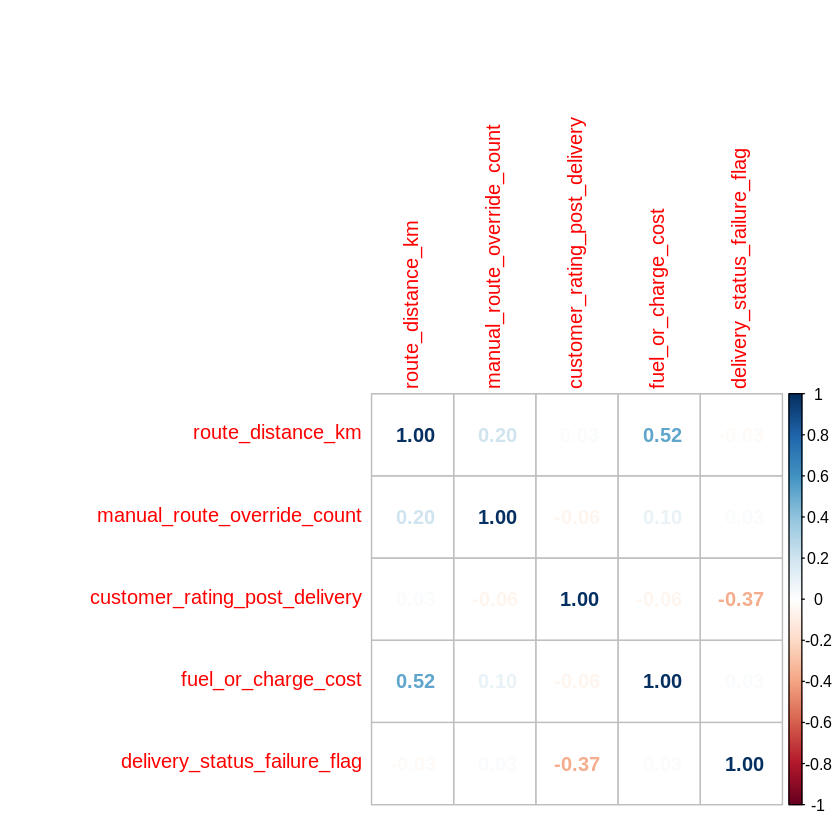

In [18]:
corrplot(correlation_matrix, method = "number")

### Interpretation

The correlation matrix shows the strength and direction of relationships between delivery-related numerical variables. Strong positive or negative correlations may indicate operational relationships, such as whether longer route distances or manual route overrides are associated with delivery failure or lower customer ratings.

In [19]:
output_path <- "/content/r_analytics_outputs"
dir.create(output_path, showWarnings = FALSE)

write_csv(dataset_summary, file.path(output_path, "r_dataset_summary.csv"))
write_csv(descriptive_stats, file.path(output_path, "r_descriptive_statistics.csv"))
write_csv(delivery_service_analysis, file.path(output_path, "r_delivery_service_analysis.csv"))
write_csv(complaint_customer_analysis, file.path(output_path, "r_complaint_customer_analysis.csv"))

print("R analytics output CSV files exported successfully.")
print(list.files(output_path))

[1] "R analytics output CSV files exported successfully."
[1] "r_complaint_customer_analysis.csv" "r_dataset_summary.csv"            
[3] "r_delivery_service_analysis.csv"   "r_descriptive_statistics.csv"     


## R Analytics Notebook Summary

This notebook used R to perform statistical and visual analysis on the cleaned NorthStar datasets. The analysis included descriptive statistics, delivery performance analysis, customer complaint analysis, driver performance analysis, app latency analysis, and correlation analysis.

The findings show that NorthStar has generally strong delivery and customer performance, but there are still important improvement areas. These include reducing failed and delayed deliveries, improving complaint resolution, investigating low customer rating outliers, and reducing high API latency events.

The R analytics outputs support the overall coursework objective by demonstrating how R can be used for data exploration, statistical analysis, and business insight generation.